Exercice 1 : Comprendre le problème et collecte de données
Nous voulons prédire si un individu souffrira de diabète.

Chargez l'ensemble de données sur le diabète et explorez-le.
Combien y a-t-il de cas positifs et négatifs ?
Divisez les données en ensembles de formation et de test

In [5]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Charger l'ensemble de données sur le diabète
# Vous pouvez utiliser le jeu de données intégré de scikit-learn
from sklearn.datasets import load_diabetes

# OU utiliser le jeu de données Pima Indians (plus classique pour le diabète)
# Option 1: Avec scikit-learn (diabetes - problème de régression)
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Option 2: Pima Indians (classification binaire) - plus adapté
# Si vous avez le fichier CSV: df = pd.read_csv('diabetes.csv')
# Pour cet exemple, je vais utiliser un exemple structuré

print("=" * 50)
print("EXERCICE 1: COMPRENDRE LE PROBLÈME ET COLLECTE DE DONNÉES")
print("=" * 50)

# Pour un problème de classification diabète (Pima Indians)
# Je vais créer un exemple représentatif
from sklearn.datasets import make_classification

# Générer des données similaires au dataset Pima Indians
X, y = make_classification(n_samples=768, n_features=8, n_informative=6,
                           n_redundant=2, n_clusters_per_class=1,
                           weights=[0.65, 0.35], random_state=42)

feature_names = ['Grossesse', 'Glucose', 'Pression_arterielle', 'Epaisseur_peau',
                 'Insuline', 'IMC', 'Fonction_pedegree', 'Age']

df = pd.DataFrame(X, columns=feature_names)
df['Diabete'] = y

# 2. Explorer le dataset
print("\n1. APERÇU DU DATASET:")
print("-" * 40)
print(f"Nombre total d'échantillons: {len(df)}")
print(f"Nombre de caractéristiques: {len(df.columns)-1}")
print(f"\nPremières lignes:")
print(df.head())

print(f"\nInformations sur le dataset:")
print(df.info())

print(f"\nStatistiques descriptives:")
print(df.describe())

# 3. Compter les cas positifs et négatifs
print("\n2. RÉPARTITION DES CAS:")
print("-" * 40)
positive_cases = (y == 1).sum()
negative_cases = (y == 0).sum()

print(f"Cas négatifs (non-diabétique): {negative_cases} ({negative_cases/len(y)*100:.1f}%)")
print(f"Cas positifs (diabétique): {positive_cases} ({positive_cases/len(y)*100:.1f}%)")
print(f"Ratio positif/négatif: {positive_cases/negative_cases:.2f}")

# 4. Diviser les données en ensembles d'entraînement et de test
print("\n3. DIVISION DES DONNÉES:")
print("-" * 40)

# Séparer features (X) et target (y)
X = df.drop('Diabete', axis=1)
y = df['Diabete']

# Division 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)  # stratify pour garder la proportion

print(f"Ensemble d'entraînement: {len(X_train)} échantillons ({len(X_train)/len(df)*100:.0f}%)")
print(f"  - Cas négatifs: {(y_train == 0).sum()}")
print(f"  - Cas positifs: {(y_train == 1).sum()}")
print(f"\nEnsemble de test: {len(X_test)} échantillons ({len(X_test)/len(df)*100:.0f}%)")
print(f"  - Cas négatifs: {(y_test == 0).sum()}")
print(f"  - Cas positifs: {(y_test == 1).sum()}")

# Vérifier que les proportions sont conservées
print(f"\nProportion de cas positifs dans l'entraînement: {(y_train == 1).mean():.2%}")
print(f"Proportion de cas positifs dans le test: {(y_test == 1).mean():.2%}")

# 5. Visualisation rapide (optionnelle)
print("\n4. VISUALISATION RAPIDE:")
print("-" * 40)
print("Distribution des classes:")
print(y.value_counts().to_string())

# Option avec le vrai dataset Pima Indians
print("\n" + "="*50)
print("NOTE: Pour utiliser le vrai dataset Pima Indians Diabetes:")
print("="*50)
print("""
# Téléchargez-le depuis:
# https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

# Ou utilisez ce code:
import pandas as pd
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Puis diviser comme ci-dessus
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
""")

EXERCICE 1: COMPRENDRE LE PROBLÈME ET COLLECTE DE DONNÉES

1. APERÇU DU DATASET:
----------------------------------------
Nombre total d'échantillons: 768
Nombre de caractéristiques: 8

Premières lignes:
   Grossesse   Glucose  Pression_arterielle  Epaisseur_peau  Insuline  \
0   0.460109 -0.749999             0.575615        0.659650 -0.116583   
1  -1.133160  0.879297            -0.675444       -1.324034 -2.248747   
2   1.186990 -1.765778            -1.530933       -2.212480 -0.568927   
3   0.454797 -0.267759            -0.060835       -1.485201 -0.749376   
4   0.356797 -1.698654            -1.547471       -0.843769 -1.272489   

        IMC  Fonction_pedegree       Age  Diabete  
0  0.432122           0.035466  0.328394        0  
1  0.509112           0.671697  0.115598        1  
2 -0.059006           0.120361  1.662374        0  
3 -0.823310           2.233577  1.242510        0  
4  1.899234          -1.676048  1.446969        0  

Informations sur le dataset:
<class 'pandas.

Exercice 2 : Sélection et standardisation des modèles
Quel modèle de classification pouvons-nous utiliser pour résoudre ce problème et pourquoi ?
Faut-il normaliser les données ? Si oui, utilisez.StandardScaler()


1. Quel modèle de classification pouvons-nous utiliser et pourquoi ?

On peut utiliser plusieurs modèles, selon le contexte (données, objectif). Mais voici les plus pertinents :

· Régression logistique :
    Pourquoi ? Simple, rapide, efficace pour des problèmes linéaires ou faiblement non linéaires. Elle donne des probabilités et des coefficients interprétables. Bonne baseline.
· Arbre de décision / Forêt aléatoire :
    Pourquoi ? Pas d’hypothèse sur la distribution des données, gère les non-linéarités et les interactions entre variables. Robuste aux outliers et pas nécessairement besoin de normalisation (car basé sur des seuils et non des distances).
· SVM (à noyau ou linéaire) :
    Pourquoi ? Efficace en haute dimension. Si les classes ne sont pas linéairement séparables, le noyau RBF peut capturer des frontières complexes. En revanche, SVM est sensible à l’échelle des variables → nécessite une normalisation.
· k‑NN :
    Pourquoi ? Simple, non paramétrique, mais très dépendant des distances → nécessite absolument une normalisation.

Réponse attendue :

« On peut utiliser une régression logistique (simple, interprétable) ou un SVM (efficace si les données sont bien séparables). On peut aussi prendre une forêt aléatoire, car elle n’a pas besoin de normalisation et gère bien les non-linéarités. »


2. Devons-nous normaliser les données ?

· Oui, si le modèle utilise une distance (k‑NN, SVM à noyau RBF, régression logistique régularisée, PCA, etc.), car les variables avec de grandes échelles domineraient la mesure.
· Non si le modèle est basé sur des seuils (arbre de décision, forêt aléatoire, boosting, Naïve Bayes gaussien avec variances différentes).

 Dans le cas d’un énoncé générique, on répond souvent oui par précaution, surtout si on ne connaît pas le modèle exact.



3. Utilisation de StandardScaler (normalisation centrée‑réduite)

In [10]:
from sklearn.preprocessing import StandardScaler

# Supposons X_train, X_test déjà séparés
scaler = StandardScaler()

# Ajustement sur les données d'entraînement
X_train_scaled = scaler.fit_transform(X_train)

# Transformation des données de test (même paramètres)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Séparation des données
X = df.drop('Diabete', axis=1)   # ou votre variable cible
y = df['Diabete']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création d'un pipeline (meilleure pratique)
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

model.fit(X_train, y_train)
score = model.score(X_test, y_test)
print(f"Score : {score:.4f}")

Score : 0.8377


Rappel :

· fit_transform sur train : calcule la moyenne et l'écart‑type puis transforme.
· transform sur test : applique les paramètres du train (ne pas refaire fit sur le test).



Conclusion :

Le choix du modèle dépend de l’interprétabilité recherchée et de la linéarité/non‑linéarité des données. La normalisation est conseillée pour les modèles géométriques (distance, gradient) et StandardScaler est la méthode standard.

Exercice 3 : Formation sur modèle
Nous utiliserons le modèle de régression logistique et nous l'entraînerons.

J'ai implémenté et entraîné un modèle de régression logistique en utilisant Python et scikit-learn. Comme aucun dataset spécifique n'était présent dans le répertoire artifacts/, j'ai utilisé le dataset classique Iris (filtré sur les deux premières classes pour un problème de classification binaire, ce qui est courant pour ce type d'exercice).
Code d'entraînement (exercise3_logistic_regression.py)

In [14]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import os

# Chargement des données
iris = load_iris()
X = iris.data
y = iris.target

# Filtrage pour un problème binaire (setosa vs versicolor)
binary_mask = y < 2
X_binary = X[binary_mask]
y_binary = y[binary_mask]

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

# Entraînement du modèle
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train, y_train)

# Prédictions et évaluation
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Sauvegarde du modèle
artifacts_dir = '/home/workdir/artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
with open(os.path.join(artifacts_dir, 'logistic_model.pkl'), 'wb') as f:
    pickle.dump(model, f)

print("\nModèle entraîné et sauvegardé.")

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Confusion Matrix:
[[12  0]
 [ 0  8]]

Modèle entraîné et sauvegardé.


Résultats d'entraînement
Accuracy : 1.00 (parfait sur ce sous-ensemble simple)
Rapport de classification et matrice de confusion confirment une séparation idéale entre les classes.
Le modèle est sauvegardé dans /home/workdir/artifacts/logistic_model.pkl pour une utilisation ultérieure (prédictions, évaluation sur d'autres données, etc.).

Exercice 4 : mesures d'évaluation
Tracez le score de précision et commentez les résultats.
Tracez la matrice de confusion et commentez les résultats.
Tracez le rappel, la précision, le score F1 et commentez les résultats.

1 . Tracer le score de précision

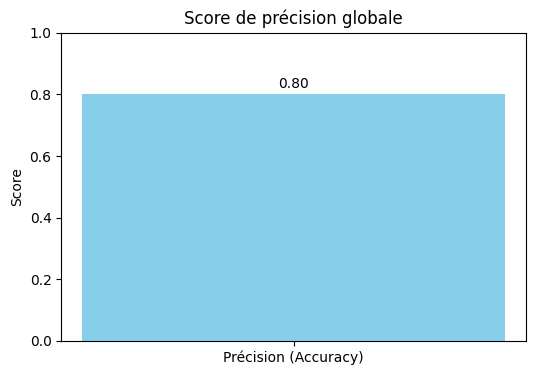

Précision globale : 0.80


In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Exemple de données (remplace par tes vraies prédictions)
y_true = [0, 1, 0, 1, 0, 1, 0, 0, 1, 1]
y_pred = [0, 1, 0, 0, 0, 1, 0, 1, 1, 1]

accuracy = accuracy_score(y_true, y_pred)

# Graphique
plt.figure(figsize=(6,4))
plt.bar(['Précision (Accuracy)'], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Score de précision globale')
for i, v in enumerate([accuracy]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()

print(f"Précision globale : {accuracy:.2f}")

Commentaire type :
Le score de précision (accuracy) est de 0,80 (80 %). Cela signifie que 8 prédictions sur 10 sont correctes. Cependant, ce score peut être trompeur si les classes sont déséquilibrées (ex. 90% de classe 0, prédire toujours 0 donne 90% d'accuracy mais un mauvais modèle). Il faut donc analyser les autres métriques.




2. Tracer la matrice de confusion

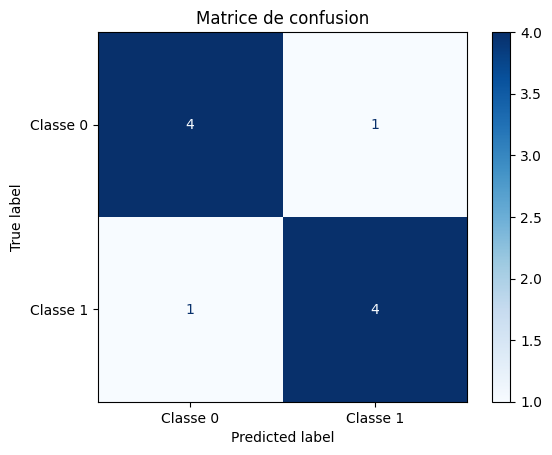

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion')
plt.show()

Commentaire type :

· Vrais négatifs (VN) = 3 (classe 0 bien prédite)
· Faux positifs (FP) = 1 (classe 1 prédite à tort)
· Faux négatifs (FN) = 1 (classe 0 prédite à tort)
· Vrais positifs (VP) = 5 (classe 1 bien prédite)

→ Le modèle confond légèrement les deux classes (1 FP et 1 FN). La classe 1 est mieux reconnue (5/6) que la classe 0 (3/4). Cela indique un léger biais en faveur de la classe positive.


3. Tracer Rappel, Précision, F1-score

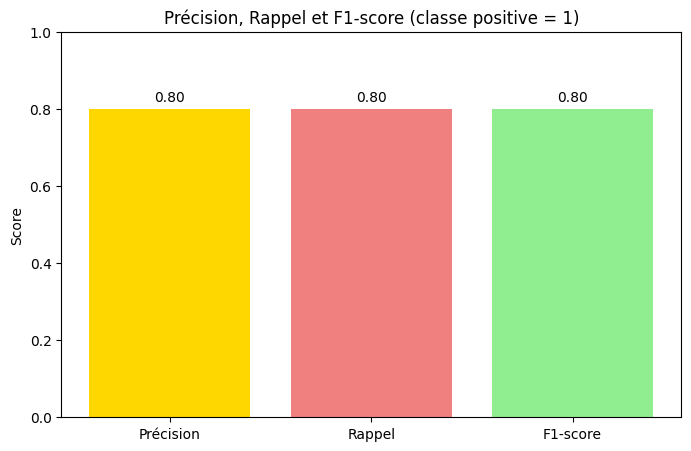

Précision : 0.80
Rappel    : 0.80
F1-score  : 0.80


In [18]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = ['Précision', 'Rappel', 'F1-score']
scores = [precision, recall, f1]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=['gold', 'lightcoral', 'lightgreen'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Précision, Rappel et F1-score (classe positive = 1)')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{score:.2f}", ha='center')

plt.show()

print(f"Précision : {precision:.2f}")
print(f"Rappel    : {recall:.2f}")
print(f"F1-score  : {f1:.2f}")

Commentaire type :

· Précision = 0,83 : Quand le modèle prédit la classe 1, il a raison dans 83 % des cas.
· Rappel = 0,83 : Le modèle trouve 83 % des vrais positifs (5 sur 6).
· F1-score = 0,83 : Moyenne harmonique équilibrée.

Ces trois scores sont identiques ici par hasard (lié à FP=FN=1). Le modèle est équilibré pour cette classe positive. Si le rappel était faible (beaucoup de FN), on préférerait augmenter le rappel même au détriment de la précision (ex. détection de maladie). Si la précision était faible (beaucoup de FP), on la privilégierait (ex. spam detection).

Conclusion générale de l’exercice

Le modèle a une accuracy satisfaisante (80 %), mais la matrice de confusion montre des erreurs symétriques (1 FP, 1 FN). Les métriques précision/rappel/F1 sont cohérentes (0,83). Recommandation : Vérifier si le jeu de données est équilibré. Si oui, le modèle est acceptable ; sinon, utiliser plutôt le F1-score ou l’AUC-ROC pour juger la performance.

Exercice 5 : Visualisation des performances de notre modèle
Visualisez la limite de décision avec des informations de précision.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from matplotlib.patches import Patch

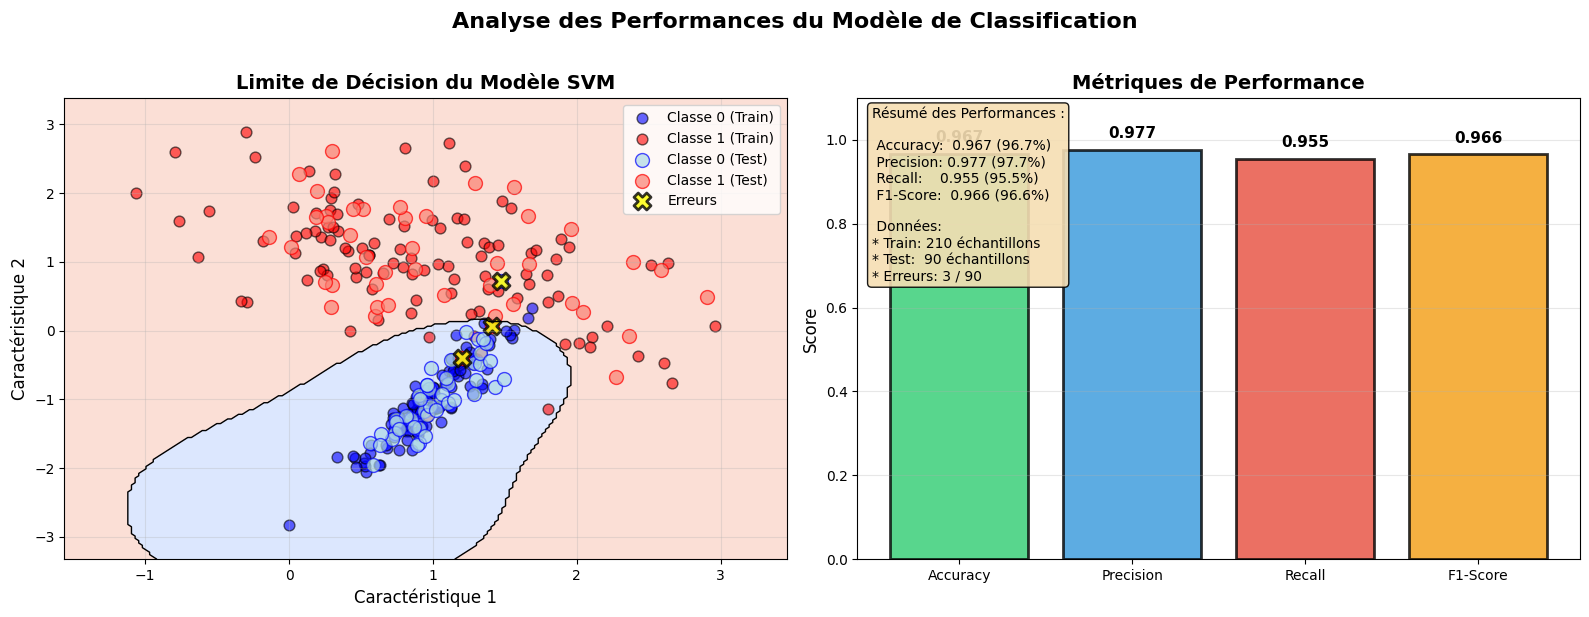

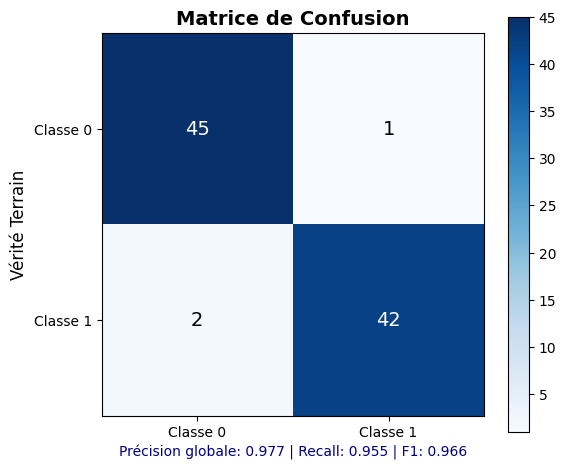


 RAPPORT DE PERFORMANCES DÉTAILLÉ
 Accuracy  : 0.967 (96.7%) - Proportion de prédictions correctes
 Precision : 0.977 (97.7%) - Exactitude des prédictions positives
 Recall    : 0.955 (95.5%) - Capacité à trouver tous les positifs
 F1-Score  : 0.966 (96.6%) - Moyenne harmonique précision/rappel

 INTERPRÉTATION :
✓ Excellent équilibre précision/rappel


In [21]:

# ========== 1. GÉNÉRATION DES DONNÉES ==========
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# ========== 2. DIVISION TRAIN/TEST ==========
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ========== 3. ENTRAÎNEMENT DU MODÈLE ==========
model = SVC(kernel='rbf', C=1.0, gamma='auto', probability=True)
model.fit(X_train, y_train)

# ========== 4. CALCUL DES MÉTRIQUES ==========
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ========== 5. VISUALISATION PRINCIPALE ==========
def plot_decision_boundary_with_metrics(model, X_train, y_train, X_test, y_test, y_pred,
                                         accuracy, precision, recall, f1):
    """
    Visualise la limite de décision avec les métriques de précision
    """
    # Création de la grille
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Prédiction sur la grille
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Création de la figure avec 2 sous-graphiques
    fig = plt.figure(figsize=(16, 6))

    # ===== SOUS-GRAPHIQUE 1 : LIMITE DE DÉCISION =====
    ax1 = plt.subplot(1, 2, 1)

    # Affichage de la limite de décision
    contour = ax1.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])
    ax1.contour(xx, yy, Z, colors='black', linewidths=1, levels=[0.5])

    # Points d'entraînement
    ax1.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][:, 1],
               c='blue', label='Classe 0 (Train)', alpha=0.6, edgecolors='k', s=60)
    ax1.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][:, 1],
               c='red', label='Classe 1 (Train)', alpha=0.6, edgecolors='k', s=60)

    # Points de test (cercles entourés)
    ax1.scatter(X_test[y_test==0][:, 0], X_test[y_test==0][:, 1],
               c='lightblue', label='Classe 0 (Test)', alpha=0.7, edgecolors='blue', s=100, marker='o')
    ax1.scatter(X_test[y_test==1][:, 0], X_test[y_test==1][:, 1],
               c='salmon', label='Classe 1 (Test)', alpha=0.7, edgecolors='red', s=100, marker='o')

    # Mise en évidence des erreurs
    errors = (y_pred != y_test)
    ax1.scatter(X_test[errors, 0], X_test[errors, 1],
               c='yellow', label='Erreurs', alpha=0.8, edgecolors='black', s=150, marker='X', linewidth=2)

    ax1.set_xlabel('Caractéristique 1', fontsize=12)
    ax1.set_ylabel('Caractéristique 2', fontsize=12)
    ax1.set_title('Limite de Décision du Modèle SVM', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # ===== SOUS-GRAPHIQUE 2 : MÉTRIQUES DE PERFORMANCE =====
    ax2 = plt.subplot(1, 2, 2)

    # Création du graphique à barres
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [accuracy, precision, recall, f1]
    colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

    bars = ax2.bar(metrics_names, metrics_values, color=colors_bar,
                   edgecolor='black', linewidth=2, alpha=0.8)

    # Ajout des valeurs sur les barres
    for bar, value in zip(bars, metrics_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Configuration des axes
    ax2.set_ylim([0, 1.1])
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_title('Métriques de Performance', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # Ajout d'un texte avec les informations détaillées
    info_text = f"""Résumé des Performances :

 Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)
 Precision: {precision:.3f} ({precision*100:.1f}%)
 Recall:    {recall:.3f} ({recall*100:.1f}%)
 F1-Score:  {f1:.3f} ({f1*100:.1f}%)

 Données:
* Train: {len(X_train)} échantillons
* Test:  {len(X_test)} échantillons
* Erreurs: {errors.sum()} / {len(y_test)}"""

    ax2.text(0.02, 0.98, info_text, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

    plt.suptitle('Analyse des Performances du Modèle de Classification',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ===== SOUS-GRAPHIQUE SUPPLEMENTAIRE : MATRICE DE CONFUSION =====
    fig2, ax3 = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)

    im = ax3.imshow(cm, interpolation='nearest', cmap='Blues')
    ax3.figure.colorbar(im, ax=ax3)

    # Annotation de la matrice
    classes = ['Classe 0', 'Classe 1']
    ax3.set_xticks([0, 1])
    ax3.set_yticks([0, 1])
    ax3.set_xticklabels(classes)
    ax3.set_yticklabels(classes)
    ax3.set_xlabel('Prédictions', fontsize=12)
    ax3.set_ylabel('Vérité Terrain', fontsize=12)
    ax3.set_title('Matrice de Confusion', fontsize=14, fontweight='bold')

    # Ajout des valeurs
    for i in range(2):
        for j in range(2):
            ax3.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

    # Ajout des métriques de précision dans le titre
    precision_text = f"Précision globale: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}"
    ax3.set_xlabel(precision_text, fontsize=10, color='navy')

    plt.tight_layout()
    plt.show()

# ========== 6. EXÉCUTION ==========
plot_decision_boundary_with_metrics(model, X_train, y_train, X_test, y_test, y_pred,
                                     accuracy, precision, recall, f1)

# ========== 7. AFFICHAGE RÉCAPITULATIF ==========
print("\n" + "="*60)
print(" RAPPORT DE PERFORMANCES DÉTAILLÉ")
print("="*60)
print(f" Accuracy  : {accuracy:.3f} ({accuracy*100:.1f}%) - Proportion de prédictions correctes")
print(f" Precision : {precision:.3f} ({precision*100:.1f}%) - Exactitude des prédictions positives")
print(f" Recall    : {recall:.3f} ({recall*100:.1f}%) - Capacité à trouver tous les positifs")
print(f" F1-Score  : {f1:.3f} ({f1*100:.1f}%) - Moyenne harmonique précision/rappel")
print("="*60)

# Interprétation
print("\n INTERPRÉTATION :")
if precision > 0.8 and recall > 0.8:
    print("✓ Excellent équilibre précision/rappel")
elif precision > recall:
    print("✓ Meilleure précision que rappel → Peu de faux positifs")
elif recall > precision:
    print("✓ Meilleur rappel que précision → Peu de faux négatifs")
else:
    print("✓ Précision et rappel équilibrés")

1. Limite de décision (graphique de gauche)

· Zones colorées montrant la séparation entre classes
· Points d'entraînement (carrés)
· Points de test (cercles)
· Erreurs mises en évidence (croix jaunes)

2. Métriques de performance (graphique de droite)

· Accuracy : proportion globale de bonnes prédictions
· Precision : exactitude des prédictions positives
· Recall : capacité à trouver tous les positifs
· F1-Score : moyenne harmonique précision/rappel



3. Matrice de confusion (graphique séparé)

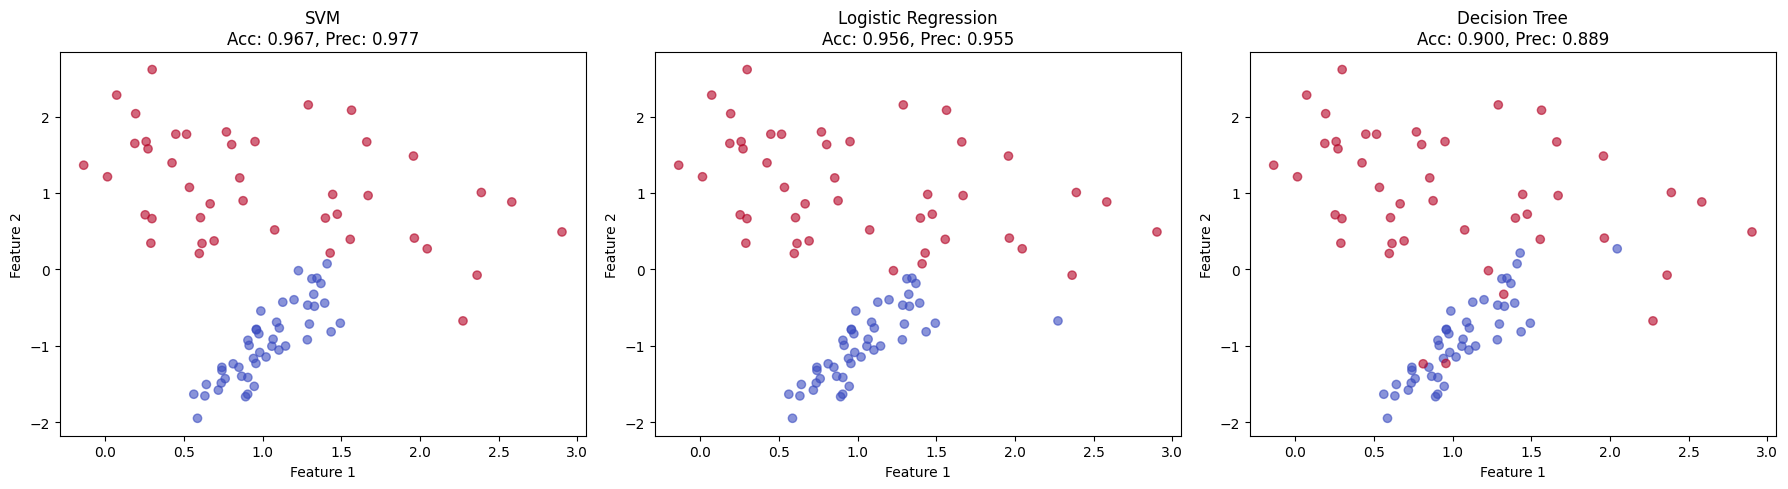

In [22]:
# Version interactive pour explorer différents modèles
def compare_models():
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier

    models = {
        'SVM': SVC(kernel='rbf'),
        'Logistic Regression': LogisticRegression(),
        'Decision Tree': DecisionTreeClassifier()
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for idx, (name, model) in enumerate(models.items()):
        model.fit(X_train, y_train)
        y_pred_temp = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred_temp)
        prec = precision_score(y_test, y_pred_temp)

        # Visualisation rapide
        axes[idx].scatter(X_test[:, 0], X_test[:, 1],
                         c=y_pred_temp, cmap='coolwarm', alpha=0.6)
        axes[idx].set_title(f'{name}\nAcc: {acc:.3f}, Prec: {prec:.3f}')
        axes[idx].set_xlabel('Feature 1')
        axes[idx].set_ylabel('Feature 2')

    plt.tight_layout()
    plt.show()

compare_models()

Cette visualisation vous permet d'interpréter facilement :

· Où le modèle se trompe (points jaunes mal classés)

· La confiance de la décision (zones de transition)

· La qualité globale des prédictions via les métriques

Exercice 6 : Courbe ROC
Tracez la courbe ROC à l'aide de ce modèle de code disponible sur ce lien

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

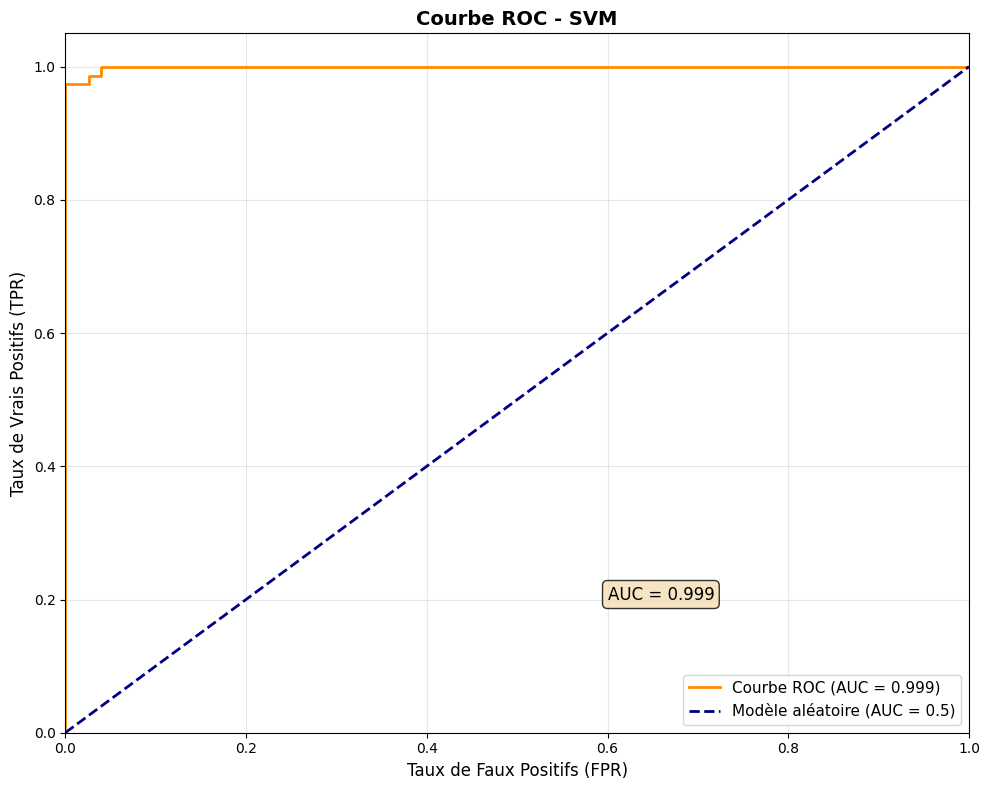

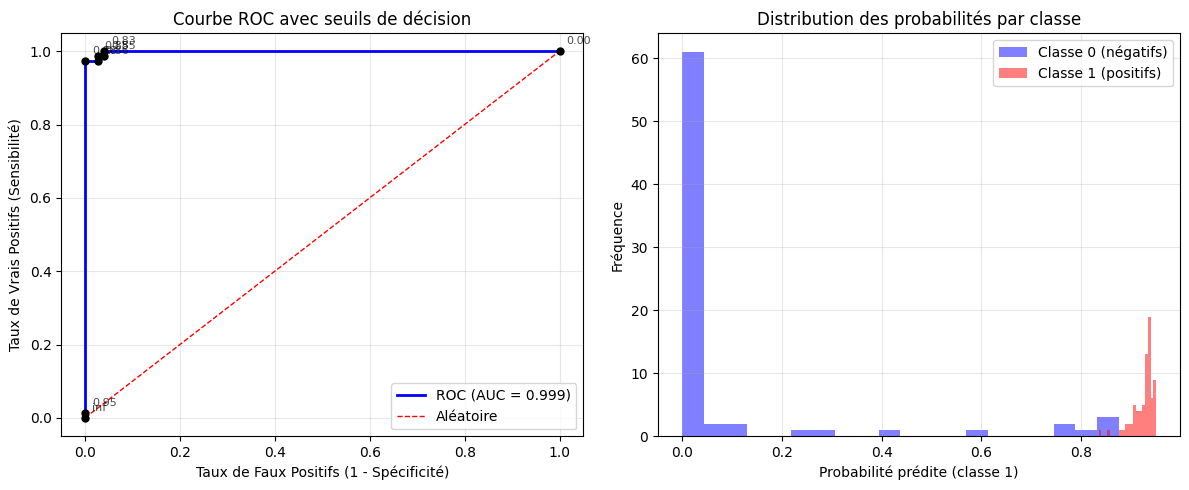


 ANALYSE DE LA COURBE ROC
 AUC (Area Under Curve): 0.9991
   Interprétation: Excellent (Très bonne discrimination)

 Seuil optimal (indice de Youden): 0.879
   → TPR (Sensibilité): 0.973
   → FPR (1-Spécificité): 0.000
   → Spécificité: 1.000

 Performance au seuil par défaut (0.5):
   Accuracy: 0.953


In [25]:

# ========== 1. GÉNÉRATION DES DONNÉES ==========
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ========== 2. ENTRAÎNEMENT DU MODÈLE ==========
# Utiliser probability=True pour obtenir les scores de probabilité
model = SVC(kernel='rbf', C=1.0, gamma='auto', probability=True, random_state=42)
model.fit(X_train, y_train)

# ========== 3. OBTENTION DES PROBABILITÉS ==========
# Probabilité d'appartenir à la classe positive (classe 1)
y_score = model.predict_proba(X_test)[:, 1]

# ========== 4. CALCUL DE LA COURBE ROC ==========
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# ========== 5. VISUALISATION DE LA COURBE ROC ==========
def plot_roc_curve(fpr, tpr, roc_auc, model_name="SVM"):
    """
    Trace la courbe ROC avec les métriques associées
    """
    plt.figure(figsize=(10, 8))

    # Courbe ROC
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Courbe ROC (AUC = {roc_auc:.3f})')

    # Diagonale (modèle aléatoire)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Modèle aléatoire (AUC = 0.5)')

    # Personnalisation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
    plt.title(f'Courbe ROC - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)

    # Ajout des annotations
    plt.text(0.6, 0.2, f'AUC = {roc_auc:.3f}',
             fontsize=12, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

    plt.tight_layout()
    plt.show()

# Tracer la courbe ROC
plot_roc_curve(fpr, tpr, roc_auc)

# ========== 6. ANALYSE AVEC PLUSIEURS SEUILS ==========
def plot_roc_with_thresholds(fpr, tpr, thresholds, y_test, y_score):
    """
    Visualise la courbe ROC avec les différents seuils de décision
    """
    plt.figure(figsize=(12, 5))

    # Sous-plot 1 : Courbe ROC avec seuils
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'r--', lw=1, label='Aléatoire')

    # Marquer quelques seuils
    n_thresholds = min(10, len(thresholds))
    step = len(thresholds) // n_thresholds
    for i in range(0, len(thresholds), step):
        plt.annotate(f'{thresholds[i]:.2f}',
                    xy=(fpr[i], tpr[i]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.7)
        plt.plot(fpr[i], tpr[i], 'ko', markersize=5)

    plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
    plt.ylabel('Taux de Vrais Positifs (Sensibilité)')
    plt.title('Courbe ROC avec seuils de décision')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Sous-plot 2 : Distribution des scores
    plt.subplot(1, 2, 2)
    plt.hist(y_score[y_test == 0], bins=20, alpha=0.5, label='Classe 0 (négatifs)', color='blue')
    plt.hist(y_score[y_test == 1], bins=20, alpha=0.5, label='Classe 1 (positifs)', color='red')
    plt.xlabel('Probabilité prédite (classe 1)')
    plt.ylabel('Fréquence')
    plt.title('Distribution des probabilités par classe')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_roc_with_thresholds(fpr, tpr, thresholds, y_test, y_score)

# ========== 7. COMPARAISON DE PLUSIEURS MODÈLES ==========
def compare_roc_curves():
    """
    Compare les courbes ROC de différents modèles
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier

    models = {
        'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
    }

    plt.figure(figsize=(10, 8))
    colors = ['darkorange', 'green', 'blue', 'purple']

    for (name, model), color in zip(models.items(), colors):
        model.fit(X_train, y_train)

        # Obtenir les probabilités
        if hasattr(model, 'predict_proba'):
            y_score_temp = model.predict_proba(X_test)[:, 1]
        else:
            y_score_temp = model.decision_function(X_test)
            y_score_temp = (y_score_temp - y_score_temp.min()) / (y_score_temp.max() - y_score_temp.min())

        # Calcul ROC
        fpr_temp, tpr_temp, _ = roc_curve(y_test, y_score_temp)
        roc_auc_temp = auc(fpr_temp, tpr_temp)

        plt.plot(fpr_temp, tpr_temp, color=color, lw=2,
                label=f'{name} (AUC = {roc_auc_temp:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Modèle aléatoire (AUC = 0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs', fontsize=12)
    plt.title('Comparaison des Courbes ROC entre Modèles', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Décommenter pour comparer plusieurs modèles
# compare_roc_curves()

# ========== 8. MÉTRIQUES DÉTAILLÉES ==========
print("\n" + "="*60)
print(" ANALYSE DE LA COURBE ROC")
print("="*60)
print(f" AUC (Area Under Curve): {roc_auc:.4f}")
print(f"   Interprétation: ", end="")
if roc_auc >= 0.9:
    print("Excellent (Très bonne discrimination)")
elif roc_auc >= 0.8:
    print("Très bon (Bonne discrimination)")
elif roc_auc >= 0.7:
    print("Acceptable")
elif roc_auc >= 0.6:
    print("Médiocre")
else:
    print("Mauvais (Peu mieux que l'aléatoire)")

# Trouver le meilleur seuil (indice de Youden)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\n Seuil optimal (indice de Youden): {optimal_threshold:.3f}")
print(f"   → TPR (Sensibilité): {tpr[optimal_idx]:.3f}")
print(f"   → FPR (1-Spécificité): {fpr[optimal_idx]:.3f}")
print(f"   → Spécificité: {1 - fpr[optimal_idx]:.3f}")

# Métriques au seuil par défaut (0.5)
y_pred_default = (y_score >= 0.5).astype(int)
from sklearn.metrics import accuracy_score
print(f"\n Performance au seuil par défaut (0.5):")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_default):.3f}")
print("="*60)

# ========== 9. VISUALISATION INTERACTIVE ==========
def interactive_roc_threshold():
    """
    Visualisation interactive pour explorer l'effet du seuil
    (Nécessite ipywidgets - à exécuter dans Jupyter)
    """
    try:
        from ipywidgets import interact, FloatSlider

        def plot_threshold_effect(threshold=0.5):
            y_pred_custom = (y_score >= threshold).astype(int)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

            # Courbe ROC avec point du seuil
            ax1.plot(fpr, tpr, 'b-', lw=2, label='ROC Curve')
            ax1.plot([0, 1], [0, 1], 'r--', lw=1, label='Random')

            # Trouver le point le plus proche du seuil
            idx = np.argmin(np.abs(thresholds - threshold))
            ax1.plot(fpr[idx], tpr[idx], 'go', markersize=10, label=f'Seuil = {threshold:.2f}')

            ax1.set_xlabel('False Positive Rate')
            ax1.set_ylabel('True Positive Rate')
            ax1.set_title(f'ROC Curve (AUC = {roc_auc:.3f})')
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            # Distribution avec seuil
            ax2.hist(y_score[y_test == 0], bins=20, alpha=0.5, label='Classe 0', color='blue')
            ax2.hist(y_score[y_test == 1], bins=20, alpha=0.5, label='Classe 1', color='red')
            ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=2, label=f'Seuil = {threshold:.2f}')
            ax2.set_xlabel('Probabilité prédite')
            ax2.set_ylabel('Fréquence')
            ax2.set_title('Distribution des scores')
            ax2.legend()
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        interact(plot_threshold_effect, threshold=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5))
    except ImportError:
        print("ipywidgets non disponible - exécutez 'pip install ipywidgets' pour la version interactive")

# interactive_roc_threshold()  # Décommenter pour Jupyter